# Learning from the first trading days of an IPO
## A Bayesian study of persistence, trading intensity and remaining day-60 returns

When a company starts trading after its IPO, investors can begin observing its price movements, trading volume and volatility. I wanted to understand whether this early trading record helps forecast what happens next:

> Can the first trading days teach investors something about an IPO's performance over the rest of its first 60 trading days?

I focus on early price performance, trading intensity, IPO size and realised volatility because I could observe these variables more consistently than historical free float or lock-up provisions. I use Bayesian regressions to produce conditional distributions for the remaining benchmark-adjusted return. I test whether early strength tends to persist or reverse, whether trading intensity adds information beyond price and size, and whether early volatility helps describe future uncertainty.

I evaluate the models chronologically on later IPOs and examine the implications of missing histories. These checks help assess the evidence, but they do not eliminate sample-selection or survivorship concerns.


# 1. Research motivation and question

## 1.1 From structural IPO characteristics to observable early trading

I initially wanted to study free float and lock-up provisions, which can affect the number of shares available for trading. The public data I collected were insufficient for a reliable analysis: only 11 IPOs had the main structural variables jointly available, and the usable lock-up observations showed no variation in duration. A regression on that sample would depend heavily on modelling assumptions and priors.

I therefore built the forecasting exercise around consistently observable early price performance, trading activity, IPO size and realised volatility.

## 1.2 Main research question

Suppose I have observed trading in IPO $i$ through day $t$. My question is:

> **Does information from the first trading days help predict whether the IPO will outperform or underperform the market over the remainder of its first 60 trading days?**

I define the remaining benchmark-adjusted log return as

$$
Y_{i,t}=\sum_{s=t+1}^{60}(r_{i,s}-r_{b,s}),
$$

where $r_{i,s}$ and $r_{b,s}$ are the IPO and benchmark log returns on the same trading day. For example, $Y_{i,10}$ measures performance from the close of day 10 through the close of day 60. Positive values indicate relative outperformance.

I estimate

$$
p(Y_{i,t}\mid\mathcal I_{i,t},D_{\mathrm{historical}}),
$$

where $D_{\mathrm{historical}}$ is the historical training sample and $\mathcal I_{i,t}$ contains information observed through day $t$.

I first ask whether early relative price strength tends to persist or reverse. I then assess whether trading intensity and realised volatility improve the predictive distribution. My goal is to evaluate probabilities and uncertainty as well as the central return forecast.

## 1.3 Economic interpretation

I interpret the relationships as predictive associations. Aggregate prices and volumes do not identify institutions, retail investors, passive funds, short sellers or the direction of their trades. I therefore do not interpret trading intensity as free-float turnover, stock scarcity or investor demand, and I do not claim a causal effect on subsequent returns.

I use **gross IPO offering value** as the denominator of trading intensity. It can include newly issued shares and shares sold by existing shareholders, so it does not necessarily equal the cash raised by the company.

## 1.4 Information available at each prediction date

Before trading, I use offering size to construct a historical reference distribution for first-close-to-day-60 performance. The offer price is checked as metadata but does not enter the regression, and this reference does not predict the offer-to-first-close move.

After day $t$, I can additionally use prices, volumes and benchmark observations from sessions $1,\ldots,t$. Future benchmark returns enter the realised outcome, never the predictors.

For chronological validation, I allow a historical IPO into training only when both its listing date and its day-60 outcome date precede the validation period. This prevents an IPO with an unavailable future outcome from entering the training sample.


## Notebook roadmap

I organise the analysis in six steps:

1. Define the research question and information boundary.
2. Examine 903 usable IPOs, including 60 at or above \$1bn.
3. Separate initial IPO returns from aftermarket performance.
4. Compare M0–M3 with training-only scaling and prior calibration.
5. Fix model selection, evaluate later IPOs and demonstrate conditional forecasts.
6. Study activity normalisation, missing outcomes and large-IPO limitations.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

# Launch the notebook from the repository root.
sys.path.insert(0, str(Path("pycode").resolve()))

from features import make_cutoff_data
from bayesian_models import load_model, forecast

DATA = Path("data")
RESULTS = Path("results")
MODELS = Path("models")
benchmark = "growth"

audit = pd.read_csv(DATA / "ipo_sample.csv", parse_dates=["ipo_date", "outcome_date"])
panel = pd.read_csv(DATA / "daily_prices.csv", parse_dates=["date"], float_precision="round_trip")
predictions = pd.read_csv(RESULTS / "predictions.csv")
scores = pd.read_csv(RESULTS / "scores.csv")
coefficients = pd.read_csv(RESULTS / "coefficients.csv")
selected = pd.read_csv(RESULTS / "selected_models.csv").set_index("cutoff").model
comparisons = pd.read_csv(RESULTS / "development_comparisons.csv", index_col="comparison")
comparisons.index.name = None
selected.index.name = None

baseline = load_model(MODELS / "day1_baseline.npz")
models = {1: load_model(MODELS / "day1_intensity.npz")}
for cutoff in [5, 10, 20]:
    models[cutoff] = load_model(MODELS / f"day{cutoff}_volatility.npz")

COLORS = ["#65b5ff", "#f7b65a", "#55d5b0", "#d79af5"]
plt.style.use("dark_background")
plt.rcParams.update({
    "figure.figsize": (10, 5), "figure.facecolor": "#0a0a0a",
    "axes.facecolor": "#0a0a0a", "font.size": 11, "axes.grid": True,
    "grid.alpha": 0.2, "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.max_columns", 20)
pd.set_option("display.precision", 4)
print(f"{audit.usable.sum()} usable IPOs | snapshot 2026-09-07 | saved-results replay")

903 usable IPOs | snapshot 2026-09-07 | saved-results replay


# 2. Historical IPO sample

## 2.1 From the candidate universe to the modelling sample

I start from an operating-company IPO candidate universe rather than selecting familiar names. I exclude identified direct listings without comparable proceeds, residual blank-check companies and unresolved issuer identities. I record exclusions in the audit dataset and require a known positive gross IPO offering value for modelling.

I base these classifications on transaction structure and data quality. However, the requirement for complete subsequent histories creates a separate selection concern. The audit records my classifications; the raw universe-construction pipeline is not included, so the full candidate universe cannot be independently reconstructed from this repository.

## 2.2 Requirements for the full tape sample

For the main price-and-volume model, I require:

1. sufficient time since listing for a 60-session outcome;
2. closing prices through day 60;
3. the corresponding volume history;
4. alignment with the benchmark calendar;
5. sufficiently consistent historical price and volume units.

I classify listings without 60 elapsed trading sessions as immature. I retain available Nasdaq recoveries of missing Yahoo histories for data checks and outcome sensitivity analysis, but exclude them from the main trading-intensity sample when their adjustment conventions cannot be verified as comparable.

The resulting **joint-tape sample** requires price, volume, offering metadata and benchmark alignment together. I show the exclusion reasons below.

## 2.3 Coverage by IPO size and listing year

I compare mature candidates with usable observations by offering size and listing year. Grey bars show mature candidates and blue bars show usable histories. IPOs with unknown proceeds cannot enter the full model or be assigned a known offering-size category.

Among 68 mature candidates with gross offering value of at least \$1bn, I retain 60:

$$
60/68=88.2\%.
$$

This coverage applies only to candidates with known proceeds. I cannot infer the size distribution of IPOs with missing offering information.

I also observe lower coverage in earlier listing cohorts. This indicates changing data availability and sample composition; it does not identify the cause of missing histories. I examine missing-outcome implications in Section 15.

My final modelling sample contains 903 distinct IPO episodes, including 60 at or above \$1bn. I do not assume that their returns are statistically independent, since their trading windows can share market shocks.

I use log proceeds continuously in the regressions. The \$500m, \$1bn and \$2bn thresholds define exploratory size groups, rather than structural breakpoints.


,IPO episodes
exclusion_reason,
blank_check_company;incomplete_prices;incomplete_volume,2
blank_check_company;missing_positive_proceeds;incomplete_prices;incomplete_volume,2
direct_listing_no_comparable_proceeds,4
direct_listing_no_comparable_proceeds;incomplete_prices;incomplete_volume,2
immature,27
missing_positive_proceeds,47
missing_positive_proceeds;immature,2
missing_positive_proceeds;incomplete_prices;incomplete_volume,80
missing_positive_proceeds;incomplete_volume,1


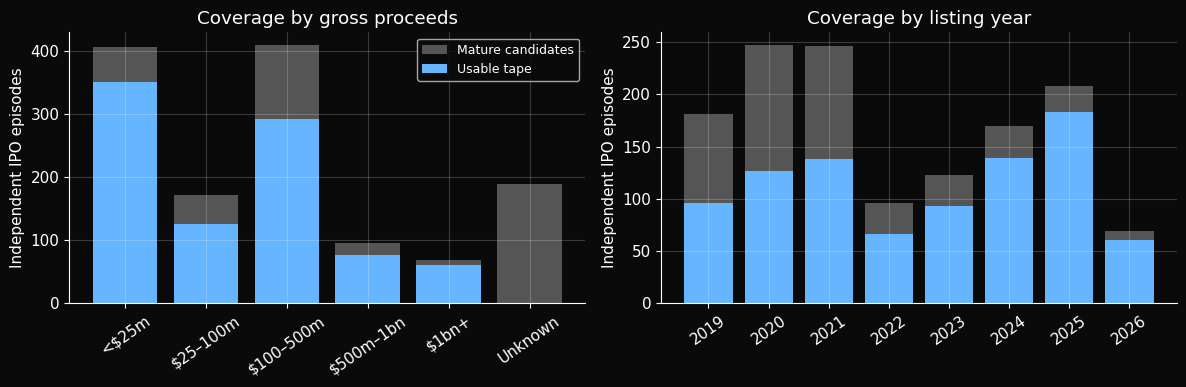

In [2]:
display(audit.groupby('exclusion_reason', dropna=False).size()
        .rename('IPO episodes').to_frame())

candidates = audit[audit.population & audit.mature].copy()
candidates['size_band'] = pd.cut(
    candidates.ipo_proceeds,
    [0, 25e6, 100e6, 500e6, 1e9, np.inf],
    labels=['<$25m', '$25–100m', '$100–500m', '$500m–1bn', '$1bn+'],
    right=False,
).cat.add_categories(['Unknown']).fillna('Unknown')
candidates['year'] = candidates.ipo_date.dt.year

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, column, label in zip(
    axes, ['size_band', 'year'], ['gross proceeds', 'listing year']
):
    counts = candidates.groupby(column, observed=True).usable.agg(['size', 'sum'])
    positions = np.arange(len(counts))
    ax.bar(positions, counts['size'], color='#555555', label='Mature candidates')
    ax.bar(positions, counts['sum'], color=COLORS[0], label='Usable tape')
    ax.set_xticks(positions, counts.index, rotation=35)
    ax.set(title='Coverage by ' + label, ylabel='Independent IPO episodes')
axes[0].legend(fontsize=9)
fig.tight_layout()
plt.show()


# 3. Constructing the event-time return and volume panel

## 3.1 Initial IPO return and aftermarket returns

I separate the initial offer-to-first-close return from subsequent aftermarket performance. Let $O_i$ be the offer price and $P_{i,1}$ the first regular-market close:

$$
IR_i=\log(P_{i,1}/O_i),\qquad
r_{i,s}=\log(P_{i,s}/P_{i,s-1}),\quad s\ge2.
$$

I start the forecasting clock at the first close and define early relative performance as

$$
\mathrm{EarlyCAR}_{i,t}=\sum_{s=2}^{t}(r_{i,s}-r_{b,s}).
$$

Thus $\mathrm{EarlyCAR}_{i,1}=0$. I exclude the offer-to-first-close move from both EarlyCAR and the retained predictors. The remaining target is

$$
Y_{i,t}=\log(P_{i,60}/P_{i,t})-\sum_{s=t+1}^{60}r_{b,s}.
$$

For example, $Y_{i,10}$ measures relative performance from the close of day 10 to the close of day 60.

I made this separation because historical prices may reflect later splits while offer prices remain in their original share units. A common constant rescaling cancels in close-to-close log returns, although correct treatment of splits within the window still depends on consistent vendor adjustments.

For the descriptive initial-return check, I matched IPOScoop observations by ticker and listing date and compared offer prices before calculating returns. I obtained 218 compatible matches from the available 2019–2020 overlap and flagged four offer-price mismatches. These observations do not define the main modelling sample.


,matched IPOs
offer_match,
False,4
True,218


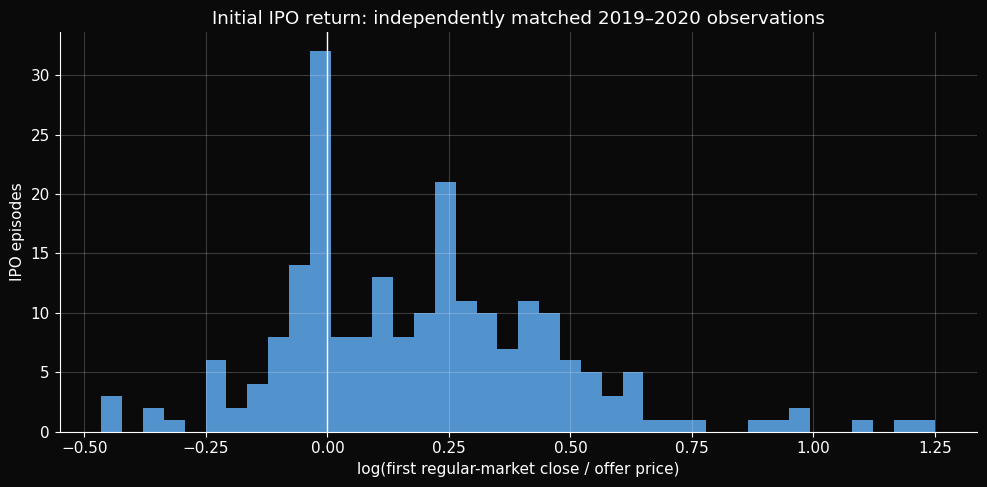

In [3]:
def plot_histogram(values, title, xlabel):
    values = np.asarray(values, dtype=float)
    fig, ax = plt.subplots()
    ax.hist(values[np.isfinite(values)], bins=40, color=COLORS[0], alpha=0.8)
    ax.axvline(0, color="white", linewidth=1)
    ax.set(title=title, xlabel=xlabel, ylabel="IPO episodes")
    fig.tight_layout()


initial = pd.read_csv(DATA / 'initial_returns.csv')
display(initial.groupby('offer_match').size().rename('matched IPOs').to_frame())
plot_histogram(
    initial.loc[initial.offer_match, 'initial_return_verified'],
    'Initial IPO return: independently matched 2019–2020 observations',
    'log(first regular-market close / offer price)',
)
plt.show()


I see substantial variation in initial returns: some IPOs finish below the offer price, many close near or above it, and a few have large positive moves. I interpret this as a description of the matched 2019–2020 observations, rather than a complete estimate of historical IPO initial returns.

## 3.2 Benchmark-adjusted performance

I compare IPO performance with two price-index benchmarks: the **S&P 500** and the **Nasdaq Composite**. For each session,

$$
x_{i,s}=r_{i,s}-r_{b,s}.
$$

Positive values indicate relative outperformance. I use benchmark returns aligned to the IPO observations, calculated on each index's valid calendar without interpolating missing index prices. These are index-relative price returns, not estimates of risk-adjusted alpha.

## 3.3 Trading intensity

I measure cumulative trading intensity as

$$
TI_{i,t}=\frac{\sum_{s=1}^{t}P_{i,s}V_{i,s}}{\mathrm{GrossIPOProceeds}_i}.
$$

Here $P_{i,s}$ is the closing price and $V_{i,s}$ is daily share volume. Their product is a **proxy for dollar turnover**; exact dollar turnover would require transaction-level prices and volumes.

For example, a \$5bn offering with \$10bn of cumulative turnover measured by this proxy has $TI=2$. I use the ratio to compare activity across offering sizes. It does not measure free-float turnover or identify who traded.

With consistent split rescaling, $P'=P/k$ and $V'=kV$, so $P'V'=PV$. A common constant price rescaling also leaves close-to-close log returns unchanged. These properties motivate the proxy, but they do not certify every vendor's adjustment conventions.

Because intensity is strongly right-skewed, I use $\log(1+TI)$ in the regressions. This preserves the ordering of observations while reducing the influence of extreme values on the predictor scale.

## 3.4 Realised uncertainty

I measure realised volatility as

$$
RV_{i,t}=\sqrt{\sum_{s=2}^{t}r_{i,s}^{2}}.
$$

EarlyCAR describes relative price direction; RV describes the magnitude of price fluctuations. An IPO can have little cumulative return and substantial realised volatility.

## 3.5 Distribution of aftermarket outcomes

I restrict the initial descriptive exploration to IPOs whose listing and day-60 outcome dates both precede 2022. This keeps the plots within the information available before the first validation block. At day 10,

$$
Y_{i,10}+\mathrm{EarlyCAR}_{i,10}
$$

is the first-close-to-day-60 excess log return. I plot this distribution below.


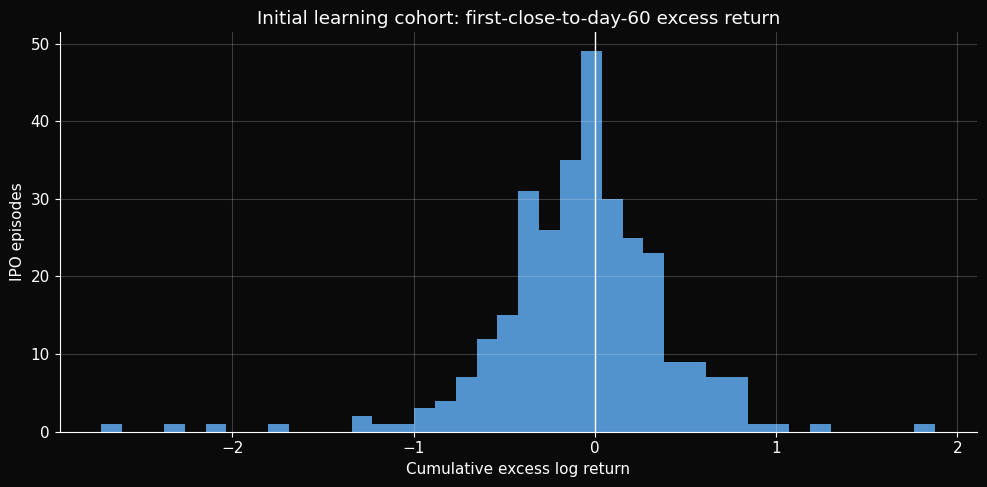

In [4]:
day10 = make_cutoff_data(audit, panel, cutoff=10, benchmark=benchmark)
# Descriptive exploration uses only the initial learning cohort.
explore = day10[
    (day10.ipo_date < '2022-01-01') & (day10.outcome_date < '2022-01-01')
]
plot_histogram(
    explore.y + explore.early_car,
    'Initial learning cohort: first-close-to-day-60 excess return',
    'Cumulative excess log return',
)
plt.show()


I interpret values near zero as approximate benchmark matching, negative values as underperformance and positive values as outperformance.

The distribution has substantial tail observations. This motivated my comparison of Gaussian and Student-$t$ likelihoods: Student-$t$ errors allow heavier tails. I assess that choice using chronological predictive scores rather than relying on the histogram alone.


# 4. Validating offered-share proxies

I compare the offered-share count implied by gross proceeds and offer price with the count extracted from SEC filings:

$$
\widehat S_i=\mathrm{GrossIPOProceeds}_i/O_i,\qquad
RE_i=(\widehat S_i-S_i^{SEC})/S_i^{SEC}.
$$

I use this as a selective check of the offering metadata. It does not validate historical free float or establish complete coverage of structural IPO characteristics.


,value
validated_IPOs,5.9000e+01
median_absolute_percentage_error,0.0000e+00
max_absolute_relative_error,8.3333e-10
rank_correlation,1.0000e+00
log_error_sd,1.3449e-10
log_actual_shares_sd,8.3502e-01


,relative error
0.0,0.0000e+00
0.1,0.0000e+00
0.5,0.0000e+00
0.9,0.0000e+00
1.0,8.3333e-10


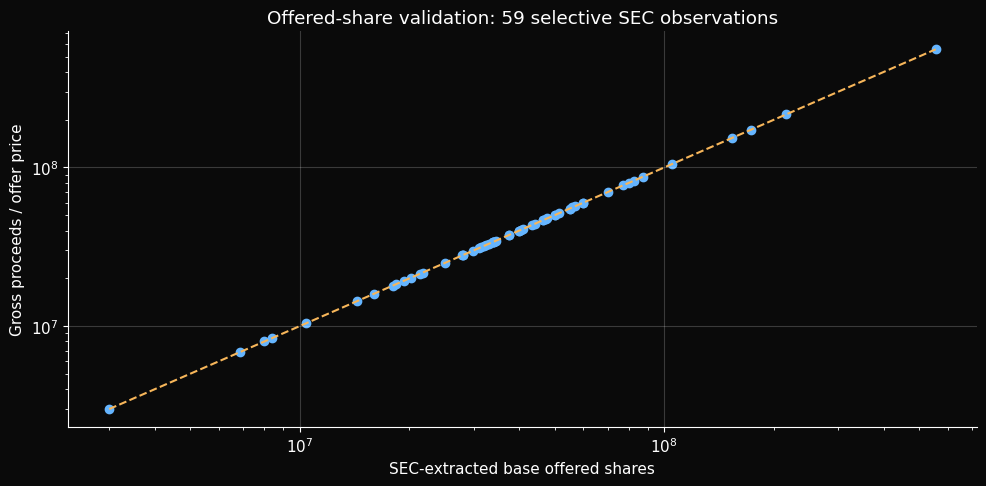

In [5]:
share_validation = pd.read_csv(DATA / 'offered_shares.csv')
share_stats = pd.Series({
    'validated_IPOs': len(share_validation),
    'median_absolute_percentage_error': share_validation.relative_error.abs().median(),
    'max_absolute_relative_error': share_validation.relative_error.abs().max(),
    'rank_correlation': share_validation[['implied', 'ipo_shares_offered']]
        .corr(method='spearman').iloc[0, 1],
    'log_error_sd': share_validation.log_error.std(),
    'log_actual_shares_sd': share_validation.log_actual.std(),
})
display(share_stats.to_frame('value'))
display(share_validation.relative_error.quantile([0, 0.1, 0.5, 0.9, 1])
        .to_frame('relative error'))

fig, ax = plt.subplots()
ax.scatter(share_validation.ipo_shares_offered, share_validation.implied,
           color=COLORS[0])
lower = min(share_validation.ipo_shares_offered.min(), share_validation.implied.min())
upper = max(share_validation.ipo_shares_offered.max(), share_validation.implied.max())
ax.plot([lower, upper], [lower, upper], color=COLORS[1], linestyle='--')
ax.set(
    xscale='log', yscale='log',
    xlabel='SEC-extracted base offered shares',
    ylabel='Gross proceeds / offer price',
    title=f'Offered-share validation: {len(share_validation)} selective SEC observations',
)
fig.tight_layout()
plt.show()


I find near numerical agreement between the implied and extracted offered-share counts across these 59 observations. I interpret this cautiously because the sample is selective and the extraction confidence is recorded as medium. Agreement in this sample does not certify every offering record or the independence of all underlying source measurements.


# 5. Exploratory price-discovery evidence

Before fitting the regressions, I examine two relationships among IPOs whose listing and outcome dates both precede 2022:

1. Does stronger early relative performance correspond to stronger or weaker remaining returns?
2. Does higher trading intensity correspond to a different remaining-return distribution?

I use the first ten sessions for the predictors and the remaining sessions through day 60 for the outcome.


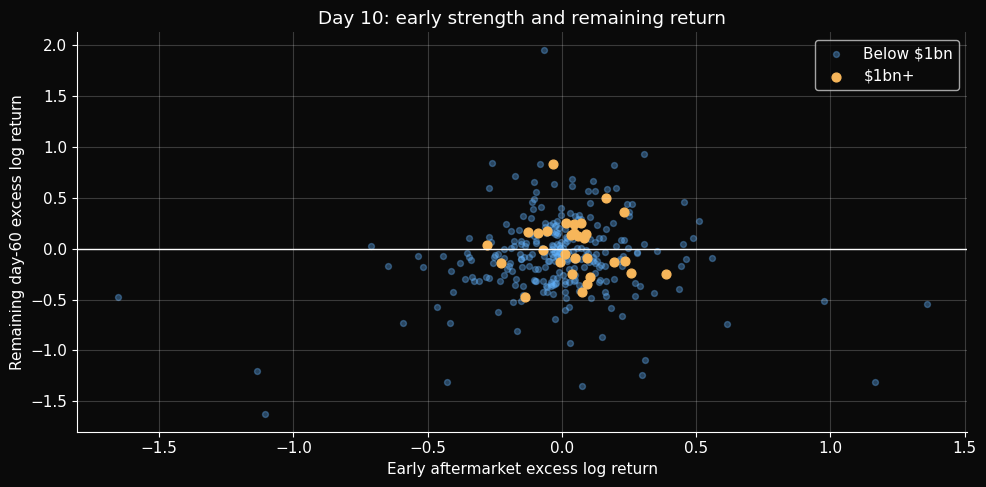

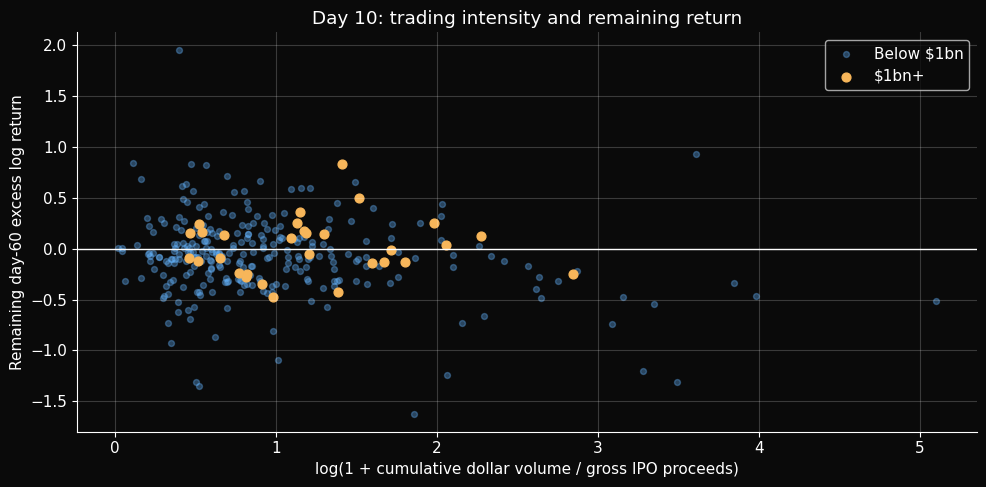

In [6]:
large = explore.ipo_proceeds >= 1e9
for column, xlabel, title in [
    ('early_car', 'Early aftermarket excess log return',
     'Day 10: early strength and remaining return'),
    ('log_ti', 'log(1 + cumulative dollar volume / gross IPO proceeds)',
     'Day 10: trading intensity and remaining return'),
]:
    fig, ax = plt.subplots()
    ax.scatter(explore.loc[~large, column], explore.loc[~large, 'y'],
               s=18, alpha=0.35, color=COLORS[0], label='Below $1bn')
    ax.scatter(explore.loc[large, column], explore.loc[large, 'y'],
               s=40, color=COLORS[1], label='$1bn+')
    ax.axhline(0, color='white', linewidth=1)
    ax.set(xlabel=xlabel, ylabel='Remaining day-60 excess log return', title=title)
    ax.legend()
    fig.tight_layout()
    plt.show()


I see considerable dispersion in both plots. IPOs with similar early relative returns can have very different remaining outcomes, and the same is true for IPOs with similar trading intensity. A few highly active listings have negative remaining returns, but I do not treat the scatter plot as sufficient evidence of a predictive relationship.

This dispersion is why I evaluate a predictive distribution: I want to assess event probabilities and the range of plausible outcomes alongside the central forecast. Regression can represent uncertainty too; my Bayesian specification makes parameter uncertainty explicit and combines it with variation in IPO outcomes.


# 6. Bayesian research design

## 6.1 Prior, likelihood and posterior predictive distribution

I use Bayesian regression to estimate the distribution of a new IPO's remaining return conditional on its observed predictors. Bayes' rule gives

$$
p(\theta\mid D)\propto p(D\mid\theta)p(\theta),\qquad
p(Y_{\mathrm{new}}\mid X_{\mathrm{new}},D)=\int p(Y_{\mathrm{new}}\mid X_{\mathrm{new}},\theta)p(\theta\mid D)\,d\theta.
$$

I use the prior to regularise plausible parameter values, the likelihood to relate parameters to observed returns, and the posterior to describe parameter uncertainty after fitting. The predictive distribution combines that uncertainty with variation in individual IPO outcomes.

I fit separate models at days 1, 5, 10 and 20. For the retained Student-$t$ specification,

$$
Y_{i,t}\mid\theta_t,X_{i,t}\sim t_{\nu_t}(\mu_{i,t},\sigma_{i,t}).
$$

I model the conditional location using offering size, early relative returns and trading intensity. In M3, I also allow realised volatility to affect the scale. The location is the conditional mean of the log-return likelihood because $\nu_t>2$; the Student-$t$ scale is not its standard deviation.

## 6.2 Units and prior calibration

I standardise each predictor using its training-sample mean and standard deviation:

$$
z(X)=(X-\bar X_{\mathrm{train}})/s_{X,\mathrm{train}}.
$$

Location coefficients therefore describe changes associated with one training-sample standard deviation in a predictor. I calibrate the prior scale to training outcome dispersion:

$$
s_Y=\max\{\mathrm{IQR}(Y_{\mathrm{train}})/1.349,\;0.1\,\mathrm{SD}(Y_{\mathrm{train}}),\;10^{-4}\}.
$$

The second and third terms are safeguards against a very small IQR. My regularising priors are

$$
\alpha\sim N(0,s_Y^2),\quad
\beta_j\sim N(0,(s_Y/2)^2),\quad
\log\sigma\sim N(\log s_Y,0.5^2),
$$

$$
\delta_{RV}\sim N(0,0.35^2),\qquad
\nu=2+\mathrm{Exponential}(\text{mean }10).
$$

These are empirical-Bayes priors: I use training data to set their scale and hold that scale fixed during sampling. I do not interpret them as independent external knowledge. The half/double prior-width comparisons are retained as `sensitivity_0.5` and `sensitivity_2.0` in `results/scores.csv`.

I simulate 500 prior-predictive draws before posterior fitting to inspect the distributions implied by these choices. Since the scale already uses training outcomes, this is a data-calibrated plausibility check. For Student-$t$ errors, the conditional variance is $\sigma^2\nu/(\nu-2)$.

I report medians, quantiles and event probabilities rather than expected dollar prices. Although the conditional log-return likelihood has finite mean and variance, its polynomial tails imply that $E[e^Y]$ is not finite. Exponentiating a predictive median or interval endpoint remains well defined.


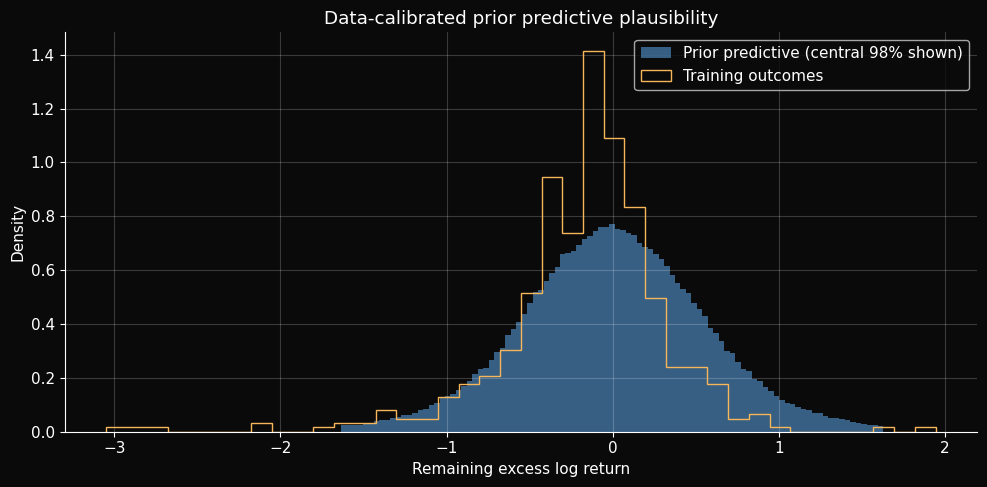

,kind,cutoff,prior_0.5%,prior_median,prior_99.5%
0,M0,1,-2.4729,0.0002,2.4623
1,M0,5,-2.1216,0.0002,2.1126
2,M0,10,-1.9893,0.0002,1.9808
3,M0,20,-1.7091,0.0002,1.7018
4,M1,5,-2.2211,0.0062,2.1970
5,M1,10,-2.0734,0.0052,2.0447
6,M1,20,-1.7713,0.0046,1.7521
7,M2,1,-2.5635,0.0114,2.5604
8,M2,5,-2.2713,-0.0004,2.2622
9,M2,10,-2.1224,0.0001,2.1052


In [7]:
prior_training = day10[
    (day10.ipo_date < '2024-01-01') & (day10.outcome_date < '2024-01-01')
]
with np.load(MODELS / "prior_check_day10.npz", allow_pickle=False) as archive:
    prior_outcomes = archive["outcome"].ravel()
lower, upper = np.quantile(prior_outcomes, [0.01, 0.99])
fig, ax = plt.subplots()
ax.hist(prior_outcomes, bins=np.linspace(lower, upper, 100), density=True,
        color=COLORS[0], alpha=0.5, label='Prior predictive (central 98% shown)')
ax.hist(prior_training.y, bins=40, density=True, histtype='step',
        color=COLORS[1], label='Training outcomes')
ax.set(xlabel='Remaining excess log return', ylabel='Density',
       title='Data-calibrated prior predictive plausibility')
ax.legend()
fig.tight_layout()
plt.show()
display(pd.read_csv(RESULTS / 'prior_summary.csv'))


I compare the representative day-10 prior-predictive distribution with its training outcomes. The prior-predictive distribution is broader and centred near zero, allowing both positive and negative returns.

I also inspect the summaries across models and cutoffs. Medians near zero are consistent with coefficient priors that do not favour persistence or reversal. Later cutoffs leave fewer trading sessions and generally have smaller outcome scales. Additional uncertain coefficients can broaden the implied distribution; these checks do not establish out-of-sample calibration.


# 7. M0 — historical reference class

I first ask what I can forecast from historical IPOs and offering size before using early trading signals. This gives the reference distribution that I use to assess additional predictors.

I compare Gaussian and Student-$t$ likelihoods and the S&P 500 and Nasdaq Composite price-index benchmarks on the two development blocks. The Student-$t$ specification has the better average log score in this screen; the benchmark difference is much smaller. I retain the Nasdaq benchmark for the main comparisons, while recognising that changing the benchmark changes the outcome being forecast.

I then compare an intercept-only baseline with one that includes log proceeds. Adding size improves average development log score at all four cutoffs, with positive lower endpoints in the IPO-bootstrap intervals. The retained M0 location is

$$
\mu_{i,t}=\alpha_t+\gamma_t\,z(\log\mathrm{Proceeds}_i),
$$

where $z$ uses training-sample scaling. I use this size-conditioned baseline for the subsequent signal comparisons so that trading intensity is assessed alongside offering size.


In [8]:
benchmark_comparison = pd.read_csv(RESULTS / "benchmark_comparison.csv", index_col="comparison")
size_comparison = pd.read_csv(RESULTS / "size_comparison.csv", index_col="cutoff")
display(benchmark_comparison.rename_axis(None))
display(size_comparison.rename_axis(None))

,held-out log score
"('growth', 'student')",-1.2048
"('broad', 'student')",-1.2116
"('growth', 'gaussian')",-1.6516
"('broad', 'gaussian')",-1.6517


,delta,lo,hi,n
1,0.1254,0.0698,0.1775,298.0
5,0.0704,0.0243,0.1141,298.0
10,0.0477,0.0090,0.0877,298.0
20,0.0472,0.0100,0.0845,298.0


# 8. M1 — early price information

I use M1 to test whether early benchmark-adjusted price performance adds predictive information beyond offering size:

$$
\mathrm{EarlyCAR}_{i,t}=\sum_{s=2}^{t}(r_{i,s}-r_{b,s}),
$$

$$
\mu_{i,t}=\alpha_t+\gamma_t z(\log\mathrm{Proceeds}_i)+\beta_{P,t}z(\mathrm{EarlyCAR}_{i,t}).
$$

I start returns at day 2 to keep the offer-to-first-close move outside the model. A common constant multiplicative price adjustment cancels in these close-to-close returns, subject to consistent treatment of corporate actions within the window.

I interpret a positive $\beta_{P,t}$ as conditional persistence and a negative coefficient as reversal. The coefficient measures a location change for one training-sample standard deviation of EarlyCAR. At day 1, EarlyCAR is zero, so M1 and M0 coincide.

At day 10, I obtain a posterior median price coefficient of approximately $0.038$, a 95% credible interval of $[0.001,0.074]$ and $P(\beta_{P,10}>0)\approx97.8\%$. On the development observations, M1 gains approximately $0.014$ nats per IPO over M0, with a 95% IPO-bootstrap interval of $[0.002,0.027]$. Its CRPS change is slightly positive, so this individual comparison does not pass the nonworsening-CRPS selection condition.

I distinguish the posterior association from predictive performance: the coefficient describes the fitted relationship, while the held-out scores assess forecasting. I consider the weaker final-cohort evidence in Section 11.


In [9]:
display(coefficients.query("phase == 'final' and kind == 'M1' and coefficient == 'early_car'")
        [['cutoff', 'median', 'lo', 'hi', 'p_positive', 'p_negative']])
display(comparisons[comparisons.index.str.endswith("M1-M0")])


,cutoff,median,lo,hi,p_positive,p_negative
84,5,0.0583,0.0120,0.0997,0.9922,0.0078
94,10,0.0375,0.0009,0.0739,0.9781,0.0219
104,20,0.0355,0.0024,0.0679,0.9809,0.0191


,delta,lo,hi,n,crps_delta
1:M1-M0,0.0000,0.0000,0.0000,298.0,0.0000
5:M1-M0,0.0073,-0.0057,0.0215,298.0,0.0016
10:M1-M0,0.0137,0.0015,0.0271,298.0,0.0002
20:M1-M0,0.0152,0.0034,0.0282,298.0,-0.0010


# 9. M2 — price plus trading intensity

I next test whether early trading activity adds information conditional on size and early price performance. I use the closing-price-times-volume proxy

$$
TI_{i,t}=\frac{\sum_{s=1}^{t}P_{i,s}V_{i,s}}{\mathrm{GrossIPOProceeds}_i}
$$

and standardise $\log(1+TI)$ using the training sample. M2 has location

$$
\mu_{i,t}=\alpha_t+\gamma_t z(\log\mathrm{Proceeds}_i)
+\beta_{P,t}z(\mathrm{EarlyCAR}_{i,t})
+\beta_{TI,t}z(\log(1+TI_{i,t})).
$$

At day 10, I obtain a posterior median intensity coefficient of approximately $-0.105$, with a 95% credible interval of $[-0.140,-0.072]$. I interpret this as a negative conditional association, rather than evidence of selling pressure or a particular investor's demand.

In development, M2 gains approximately $0.038$ nats per IPO over M1, with a 95% IPO-bootstrap interval of $[0.008,0.072]$, and improves CRPS. This supports incremental predictive information in the development sample. I assess whether it transfers to later IPOs separately in Section 11.


In [10]:
display(coefficients.query("phase == 'final' and kind == 'M2' and coefficient == 'log_ti'")
        [['cutoff', 'median', 'lo', 'hi', 'p_positive', 'p_negative']])
display(comparisons[comparisons.index.str.endswith("M2-M1")])


,cutoff,median,lo,hi,p_positive,p_negative
81,1,-0.1862,-0.2291,-0.1426,0.0,1.0
87,5,-0.1443,-0.1847,-0.1061,0.0,1.0
97,10,-0.1054,-0.1398,-0.0716,0.0,1.0
107,20,-0.0713,-0.0996,-0.0419,0.0,1.0


,delta,lo,hi,n,crps_delta
1:M2-M1,0.0888,0.0474,0.1359,298.0,-0.0337
5:M2-M1,0.0697,0.0362,0.1093,298.0,-0.0228
10:M2-M1,0.0383,0.0075,0.0716,298.0,-0.0155
20:M2-M1,0.0256,0.0047,0.0486,298.0,-0.0070


# 10. M3 — conditional uncertainty

In M3, I retain M2's location specification and allow realised volatility to affect the scale:

$$
\log\sigma_{i,t}=\delta_{0,t}+\delta_{RV,t}z(RV_{i,t}).
$$

I refit all parameters jointly, so retaining the location specification does not mean that its fitted coefficients remain unchanged. My hypothesis concerns dispersion rather than a directional or causal volatility effect. At day 1, RV is zero and M3 coincides with M2.

At day 10, I obtain a development log-score increment of approximately $0.058$ nats per IPO, with a 95% IPO-bootstrap interval of $[0.015,0.099]$. I also require nonworsening CRPS for selection. A score improvement alone does not establish that predictive intervals are calibrated.


,delta,lo,hi,n,crps_delta
1:M3-M2,0.0000,0.0000,0.0000,298.0,0.0000
5:M3-M2,0.0426,0.0126,0.0742,298.0,-0.0054
10:M3-M2,0.0577,0.0149,0.0994,298.0,-0.0029
20:M3-M2,0.0435,0.0105,0.0773,298.0,-0.0024


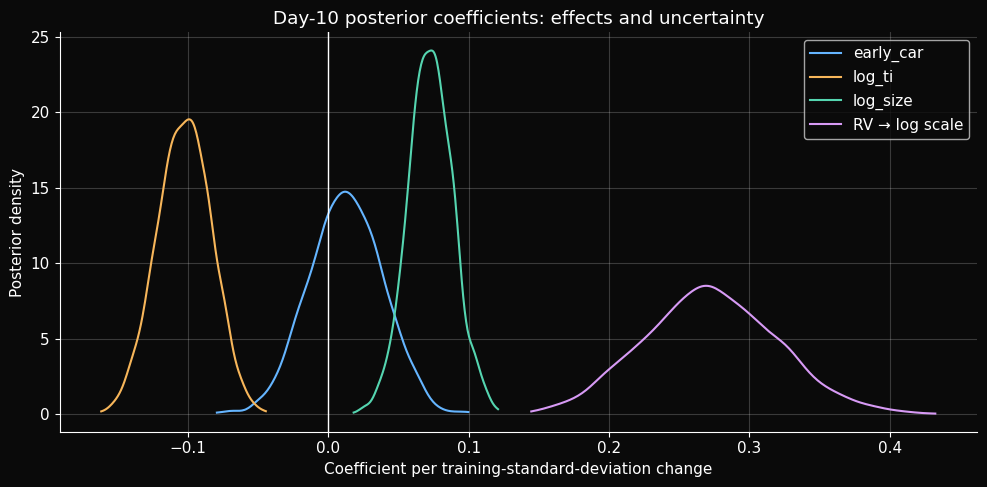

In [11]:
display(comparisons[comparisons.index.str.endswith("M3-M2")])

model = models[10]
fig, ax = plt.subplots()
for index, name in enumerate(model['names']):
    values = model['beta'][:, index]
    grid = np.linspace(*np.quantile(values, [0.001, 0.999]), 200)
    ax.plot(grid, stats.gaussian_kde(values)(grid),
            color=COLORS[index], label=name)
values = model['delta_rv']
grid = np.linspace(*np.quantile(values, [0.001, 0.999]), 200)
ax.plot(grid, stats.gaussian_kde(values)(grid), color=COLORS[3], label='RV → log scale')
ax.axvline(0, color='white', linewidth=1)
ax.set(xlabel='Coefficient per training-standard-deviation change',
       ylabel='Posterior density',
       title='Day-10 posterior coefficients: effects and uncertainty')
ax.legend()
fig.tight_layout()
plt.show()


# 11. Chronological out-of-sample model comparison

I fix the modelling choices using the development data, then evaluate the models on 244 IPOs listed in 2025–2026. I do not use this final cohort to choose predictors, prior widths or the selected model at each cutoff.

Each cutoff is a different forecasting problem: later cutoffs provide more observations but leave a shorter remaining horizon. I therefore compare models within each cutoff.

The final evidence is weaker than the development results. The selected day-1 intensity model performs worse than M0 on both log score and CRPS. At day 10, the intensity increment is approximately $-0.0017$ nats per IPO, with a 95% IPO-bootstrap interval of $[-0.0392,0.0361]$. The scale-model increment is positive at approximately $0.0321$, but its interval of $[-0.0020,0.0695]$ crosses zero.

I consider calibration the main limitation. Across the selected models, nominal 80% intervals cover roughly 65–72% of final outcomes and nominal 95% intervals cover about 86–89%. For day-10 M3, the corresponding rates are 67.6% and 86.9%. The distributions are too narrow for this cohort, even where relative scores improve.


,frozen selected model
1,M2
5,M3
10,M3
20,M3


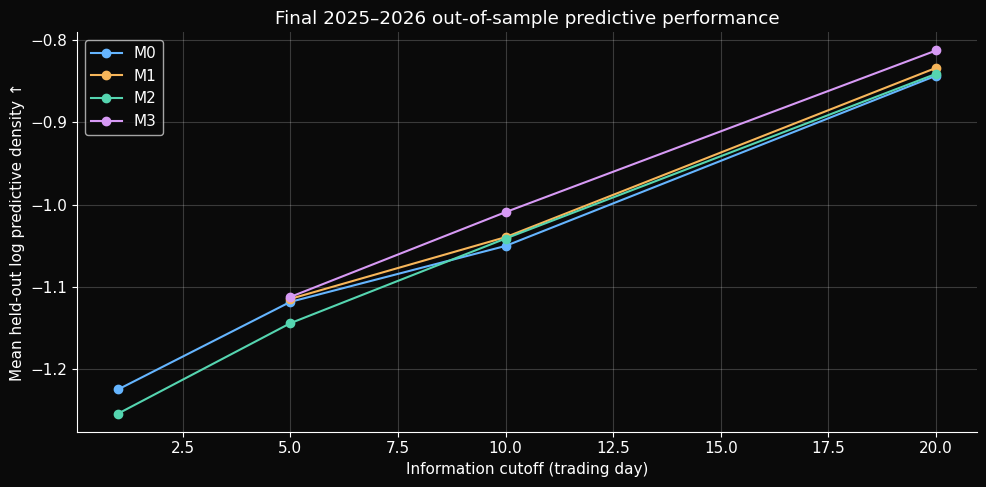

In [12]:
display(selected.rename("frozen selected model").to_frame())
final_scores = scores[
    (scores.phase == 'final') & (scores.benchmark == benchmark)
    & (scores.likelihood == 'student')
]
fig, ax = plt.subplots()
for index, kind in enumerate(['M0', 'M1', 'M2', 'M3']):
    results = final_scores[final_scores.kind == kind].sort_values('cutoff')
    ax.plot(results.cutoff, results.log_score, 'o-', color=COLORS[index], label=kind)
ax.set(xlabel='Information cutoff (trading day)',
       ylabel='Mean held-out log predictive density ↑',
       title='Final 2025–2026 out-of-sample predictive performance')
ax.legend()
fig.tight_layout()
plt.show()


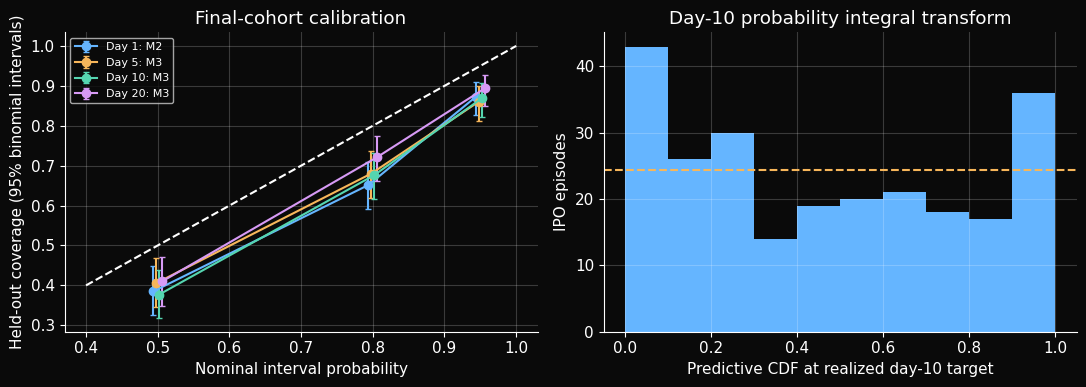

,phase,threshold,cutoff,comparison,delta,lo,hi,n
36,final,0.0,5,M1-M0,0.0036,-0.0119,0.0193,244
37,final,0.0,5,M2-M1,-0.0295,-0.0749,0.0151,244
38,final,0.0,5,M3-M2,0.0319,0.0028,0.0627,244
39,final,0.0,10,M1-M0,0.0107,-0.0021,0.0244,244
40,final,0.0,10,M2-M1,-0.0017,-0.0392,0.0361,244
41,final,0.0,10,M3-M2,0.0321,-0.0020,0.0695,244
42,final,0.0,20,M1-M0,0.0095,-0.0051,0.0239,244
43,final,0.0,20,M2-M1,-0.0073,-0.0348,0.0199,244
44,final,0.0,20,M3-M2,0.0284,0.0024,0.0562,244


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
levels = [50, 80, 95]
nominal = np.array(levels) / 100
for index, cutoff in enumerate([1, 5, 10, 20]):
    kind = selected.loc[cutoff]
    row = final_scores[(final_scores.cutoff == cutoff) & (final_scores.kind == kind)].iloc[0]
    coverage = np.array([row[f'coverage{level}'] for level in levels])
    lower = np.array([row[f'coverage{level}_lo'] for level in levels])
    upper = np.array([row[f'coverage{level}_hi'] for level in levels])
    axes[0].errorbar(nominal + (index - 1.5) * 0.004, coverage,
                     yerr=[coverage - lower, upper - coverage],
                     fmt='o-', color=COLORS[index], capsize=2,
                     label=f'Day {cutoff}: {kind}')
axes[0].plot([0.4, 1], [0.4, 1], linestyle='--', color='white')
axes[0].set(xlabel='Nominal interval probability',
            ylabel='Held-out coverage (95% binomial intervals)',
            title='Final-cohort calibration')
axes[0].legend(fontsize=8)

selected_day10 = predictions[
    (predictions.phase == 'final') & (predictions.cutoff == 10)
    & (predictions.kind == selected.loc[10])
]
axes[1].hist(selected_day10.pit, bins=np.linspace(0, 1, 11), color=COLORS[0])
axes[1].axhline(len(selected_day10) / 10, color=COLORS[1], linestyle='--')
axes[1].set(xlabel='Predictive CDF at realized day-10 target',
            ylabel='IPO episodes', title='Day-10 probability integral transform')
fig.tight_layout()
plt.show()

size_contrasts = pd.read_csv(RESULTS / 'size_comparisons.csv')
display(size_contrasts.query("phase == 'final' and threshold == 0"))


I assess log predictive density, where higher is better, and CRPS, where lower is better, using `results/scores.csv`. The score chart above shows log predictive density; the displayed paired comparisons report the increments from price, intensity and conditional scale. An interval crossing zero does not clearly establish a positive increment under the IPO-bootstrap assumptions.

I use the calibration chart to compare nominal interval probabilities with realised coverage. Each IPO receives its own predictive intervals; the coverage rate counts the outcomes that fall inside them. Points below the diagonal indicate undercoverage. The error bars are Jeffreys binomial intervals, which assume independent coverage indicators and may understate uncertainty when IPOs share calendar shocks.

I also inspect the day-10 probability integral transform (PIT). For a correctly specified continuous predictive distribution, the PIT is uniform in the population. The excess of observations near zero and one is consistent with too many realised tail outcomes. These diagnostics show why relative score gains are insufficient to claim reliable forecast probabilities.


# 12. Sequential forecasting for a live IPO

I apply frozen historical models to the information observed for a new IPO at each validated cutoff. Before trading, I use size to form a reference distribution for first-close-to-day-60 performance. After the first session, I can use intensity; at later cutoffs I also use early relative performance and realised volatility.

I do not update one issuer-specific Bayesian posterior recursively. The models are separate conditional forecasts with changing targets: day 5 forecasts from the close of day 5 to day 60, and day 20 forecasts from the close of day 20 to day 60.

I illustrate this with Medline (MDLN). The left panel shows medians and 50%, 80% and 95% predictive intervals. The orange line shows the remaining return realised at each cutoff, which would only be known after day 60. The forecast moves from a positive reference median towards a more neutral value while remaining uncertain. A relatively flat realised-target line does not imply flat daily prices because its horizon changes at each cutoff.

In the right panel, I plot

$$
P(Y_{i,t}>0)\quad\text{and}\quad P(Y_{i,t}<\log(0.8)).
$$

These are the probabilities of relative outperformance and a loss exceeding 20% in benchmark-relative wealth. The threshold is $\log(0.8)\approx-0.223$. For MDLN, I observe a decline in the outperformance probability as the trading information changes, while the large-loss probability changes less.


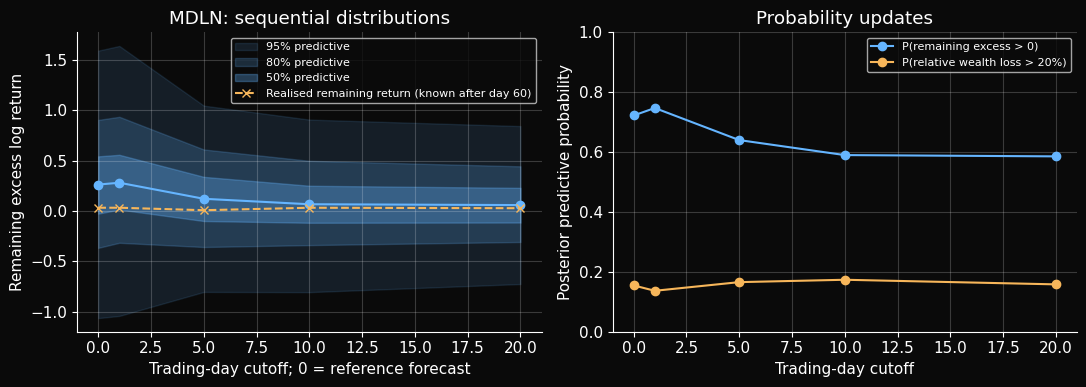

,ticker,cutoff,model,median_log,lo50,hi50,lo80,hi80,lo95,hi95,p_positive,p_loss20
0,ELOG,0,M0,-0.4931,-0.7796,-0.2083,-1.1257,0.1666,-1.8243,0.7989,0.1466,0.7364
1,ELOG,1,M2,-0.4044,-0.6709,-0.1267,-1.0095,0.2347,-1.7390,0.9044,0.1765,0.6754
2,ELOG,5,M3,-0.2746,-0.5407,-0.0088,-0.8483,0.3236,-1.4116,0.8689,0.2465,0.5576
3,ELOG,10,M3,-0.2064,-0.4452,0.0331,-0.7334,0.3487,-1.3088,0.8628,0.2835,0.4858
4,ELOG,20,M3,-0.1675,-0.3624,0.0319,-0.6006,0.2887,-1.0860,0.7704,0.2861,0.4262
5,POM,0,M0,-0.3699,-0.6545,-0.0881,-1.0020,0.2906,-1.7016,0.9260,0.2027,0.6397
6,POM,1,M2,-0.4971,-0.7611,-0.2244,-1.0926,0.1478,-1.8045,0.8203,0.1373,0.7458
7,POM,5,M3,-0.3782,-0.6112,-0.1345,-0.9058,0.1637,-1.4232,0.6632,0.1634,0.6703
8,POM,10,M3,-0.3165,-0.5196,-0.1048,-0.7877,0.1740,-1.2950,0.6295,0.1768,0.6165
9,POM,20,M3,-0.2549,-0.4424,-0.0689,-0.6612,0.1571,-1.1035,0.6064,0.1881,0.5518


In [14]:
pseudo = pd.read_csv(RESULTS / 'historical_forecasts.csv')
issuer_id = pseudo.loc[pseudo.ipo_proceeds >= 1e9, 'ipo_id'].iloc[0]
example = pseudo[pseudo.ipo_id == issuer_id].sort_values('cutoff')
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for level, opacity in [(95, 0.12), (80, 0.2), (50, 0.3)]:
    axes[0].fill_between(example.cutoff, example[f'lo{level}'], example[f'hi{level}'],
                         color=COLORS[0], alpha=opacity, label=f'{level}% predictive')
axes[0].plot(example.cutoff, example.median_log, 'o-', color=COLORS[0])
axes[0].plot(example.cutoff, example.realized, 'x--', color=COLORS[1],
             label='Realised remaining return (known after day 60)')
axes[0].set(xlabel='Trading-day cutoff; 0 = reference forecast',
            ylabel='Remaining excess log return',
            title=f'{example.ticker.iloc[0]}: sequential distributions')
axes[0].legend(fontsize=8)
axes[1].plot(example.cutoff, example.p_positive, 'o-', color=COLORS[0],
             label='P(remaining excess > 0)')
axes[1].plot(example.cutoff, example.p_loss20, 'o-', color=COLORS[1],
             label='P(relative wealth loss > 20%)')
axes[1].set(xlabel='Trading-day cutoff', ylabel='Posterior predictive probability',
            ylim=(0, 1), title='Probability updates')
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()
display(pseudo[['ticker', 'cutoff', 'model', 'median_log', 'lo50', 'hi50',
                'lo80', 'hi80', 'lo95', 'hi95', 'p_positive', 'p_loss20']])


# 13. Other historical demonstrations

I use the same conditional forecasting procedure for six IPOs spanning a range of offering sizes. The selected issuers, listing dates and proceeds are shown below. These examples illustrate model behaviour; they do not replace the full-cohort validation or establish representative forecast accuracy.

For each issuer, I keep the fitted historical model fixed and condition only on the observed prefix. I treat this as a historical demonstration of a forecast that could be calculated at the cutoff, subject to the limitations of retrospective vendor data.

The density curves show forecasts at the reference point and days 5, 10 and 20. Later curves can narrow both because of the new signals and because fewer sessions remain. I do not attribute all narrowing to learning.

I display a saved day-7 calculation from `results/forecast_checks.csv`. Its `future_suffix_invariant = True` value records that calculation; I do not rerun a day-7 fitted model because its fitted draws are not included.

I separately execute a day-10 check below, comparing forecasts from the complete history and from the first ten sessions only. The assertion verifies that deleting the future suffix leaves the simulated forecast draws unchanged. The checking script also tests other validated cutoffs with deliberately invalid future values. These checks test the information boundary in the forecast code; they do not establish point-in-time vendor correctness or remove sample-selection bias.


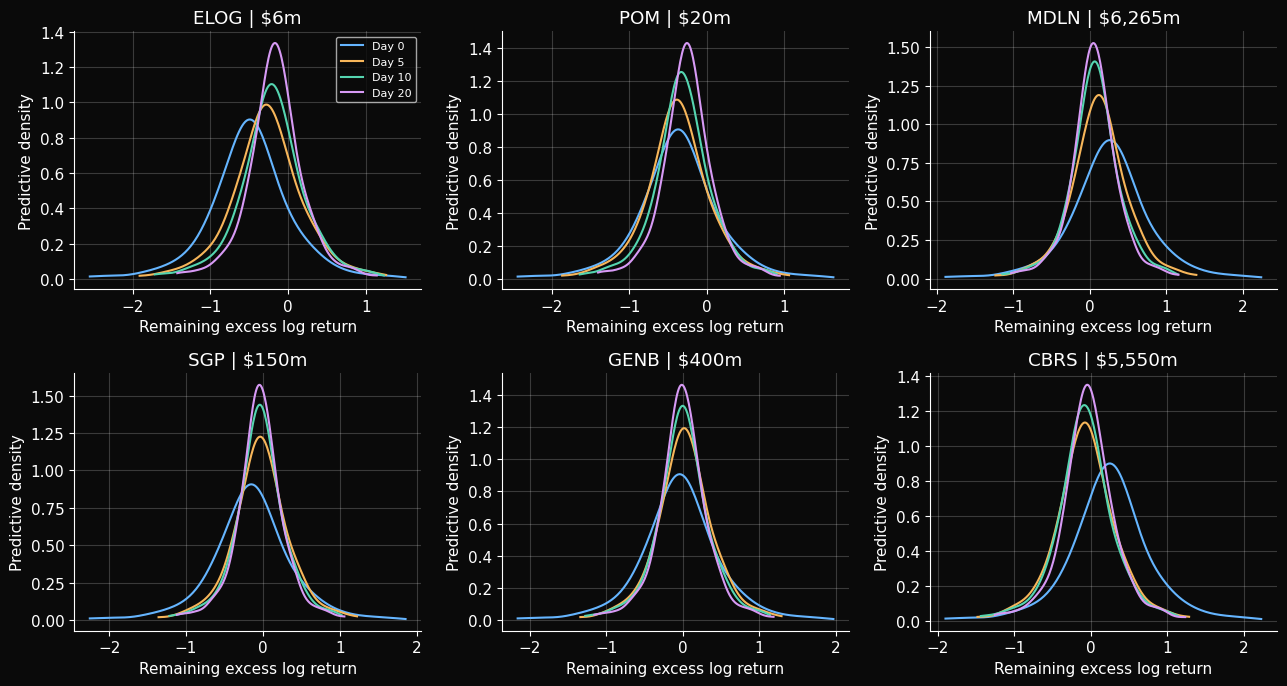

,ticker,ipo_date,ipo_proceeds
0,ELOG,2025-08-28 00:00:00,6.4000e+06
5,POM,2025-10-08 00:00:00,2.0000e+07
10,MDLN,2025-12-17 00:00:00,6.2650e+09
15,SGP,2026-02-06 00:00:00,1.5000e+08
20,GENB,2026-02-27 00:00:00,4.0000e+08
25,CBRS,2026-05-14 00:00:00,5.5500e+09


,result
arbitrary_cutoff_tested,7
future_suffix_invariant,True
model,M3
p_positive,0.1926


Day-10 future-suffix invariance: passed


In [15]:
with np.load(MODELS / "historical_forecasts.npz", allow_pickle=False) as archive:
    historical_draws = {name: archive[name] for name in archive.files}

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, issuer_id in zip(axes.flat, pseudo.ipo_id.unique()):
    example = pseudo[pseudo.ipo_id == issuer_id]
    for index, cutoff in enumerate([0, 5, 10, 20]):
        values = historical_draws[f'{issuer_id}_{cutoff}']
        grid = np.linspace(*np.quantile(values, [0.01, 0.99]), 200)
        ax.plot(grid, stats.gaussian_kde(values)(grid), color=COLORS[index],
                label=f'Day {cutoff}')
    ax.set(title=f'{example.ticker.iloc[0]} | ${example.ipo_proceeds.iloc[0] / 1e6:,.0f}m',
           xlabel='Remaining excess log return', ylabel='Predictive density')
axes.flat[0].legend(fontsize=8)
fig.tight_layout()
plt.show()
display(pseudo[['ticker', 'ipo_date', 'ipo_proceeds']].drop_duplicates())

# The day-7 calculation is retained as a saved summary.
# No day-7 fitted draws are included, so this cell does not rerun that calculation.
checks = pd.read_csv(RESULTS / "forecast_checks.csv").iloc[0]
display(checks.to_frame("result"))

# Independently check this notebook's prediction code at validated day 10.
issuer = audit.set_index('ipo_id').loc[pseudo.ipo_id.iloc[0]]
history = panel[panel.ipo_id == issuer.name].sort_values('day')
offer = dict(offer_price=issuer.offer_price, ipo_proceeds=issuer.ipo_proceeds,
             ipo_date=issuer.ipo_date)
complete = forecast(models[10], 
    **offer, prices=history.Close, volume=history.Volume,
    benchmark_returns=history[f'{benchmark}_return'],
)
prefix = forecast(models[10], 
    **offer, prices=history.Close.iloc[:10], volume=history.Volume.iloc[:10],
    benchmark_returns=history[f'{benchmark}_return'].iloc[:10],
)
assert np.array_equal(complete['draws_log_excess_return'],
                      prefix['draws_log_excess_return'])
print('Day-10 future-suffix invariance: passed')


# 14. Robustness A: price-discovery normalisation

I examine how daily trading intensity and absolute returns move towards each IPO's later activity level. Cumulative intensity and cumulative realised volatility increase mechanically, so I use daily measures for the normalisation analysis:

$$
A_{i,t}=\frac{\text{daily activity at }t}{\text{median activity over sessions 41--60}}.
$$

A ratio of one indicates the later reference level. Since the denominator uses future sessions, I interpret these ratios retrospectively and do not use them as live predictors.

I first plot cumulative activity, then the daily normalised ratios. For \$1bn+ IPOs, median daily intensity declines from roughly 17.1 times the later baseline at day 1 to 1.31 at day 10 and 1.26 at day 20. Absolute-return magnitude also declines towards its later level.

I compare constant, power-law and exponential descriptions, with the latter two given by

$$
\log A_{i,t}=a+b\log t+\epsilon_{i,t},\qquad
\log A_{i,t}=a+bt+\epsilon_{i,t}.
$$

I estimate on pre-2025 listings and compare descriptive mean squared error on later listings. The power-law form has the lowest later-cohort MSE for both variables. Its slope is approximately $-0.587$ for intensity, with a 95% IPO-bootstrap interval of $[-0.623,-0.547]$, and $-0.102$ for absolute returns, with interval $[-0.125,-0.076]$.

I resample complete IPO trajectories for slope uncertainty to retain dependence within each issuer. This does not account for common shocks across issuers. Also, 36 pre-2025 listings have outcome windows crossing into 2025, and I use the later cohort to select the best form. I therefore present this as descriptive evidence of declining activity, not an untouched predictive validation or proof of a price-discovery mechanism.


,variable,form,n_train,n_test,intercept,slope,slope_lo,slope_hi,heldout_mse,half_life_days,selected_form,selected_minus_alternative_mse,delta_lo,delta_hi
0,daily_ti,constant,649,240,0.4111,NaN,NaN,NaN,1.8399,NaN,power,-0.1089,-0.1244,-0.0949
1,daily_ti,power,649,240,2.2561,-0.5871,-0.6232,-0.5474,1.5884,NaN,power,-0.1089,-0.1244,-0.0949
2,daily_ti,exponential,649,240,1.1296,-0.0236,-0.0257,-0.0215,1.6972,NaN,power,-0.1089,-0.1244,-0.0949
3,abs_return,constant,659,240,-0.0933,NaN,NaN,NaN,1.3375,NaN,power,-0.0043,-0.0063,-0.0022
4,abs_return,power,659,240,0.2340,-0.1024,-0.1254,-0.0759,1.3286,NaN,power,-0.0043,-0.0063,-0.0022
5,abs_return,exponential,659,240,0.0078,-0.0033,-0.0044,-0.0022,1.3328,NaN,power,-0.0043,-0.0063,-0.0022


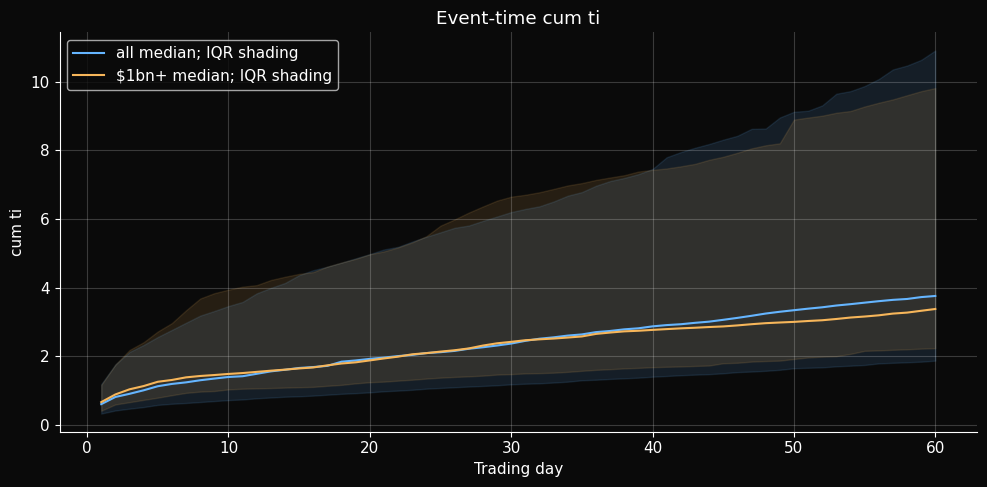

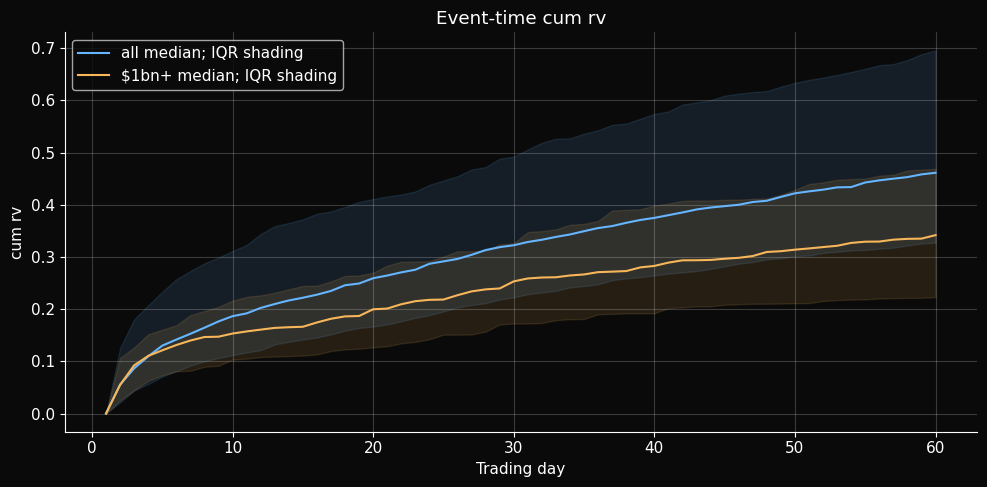

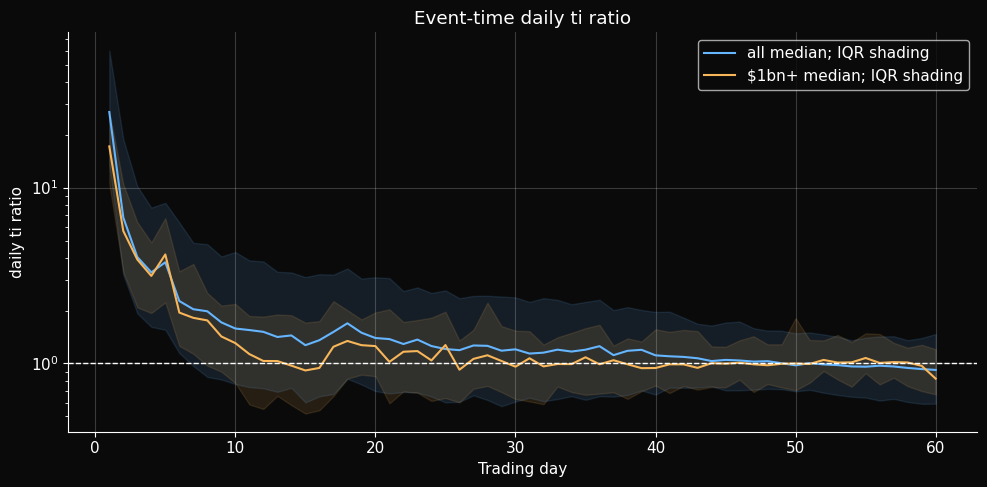

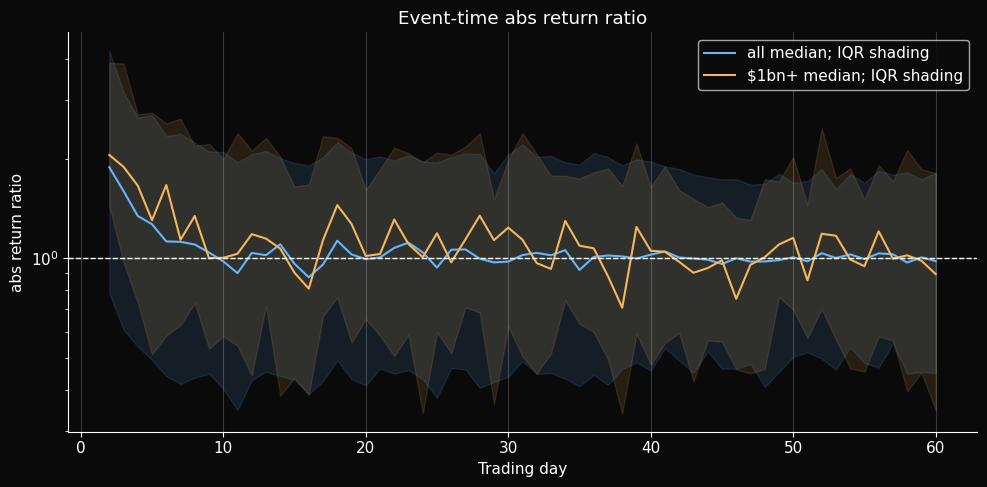

In [16]:
normalization_models = pd.read_csv(RESULTS / 'activity_models.csv')
normalization_distributions = pd.read_csv(RESULTS / 'activity_distributions.csv')
display(normalization_models)
for variable in ['cum_ti', 'cum_rv', 'daily_ti_ratio', 'abs_return_ratio']:
    fig, ax = plt.subplots()
    for index, group in enumerate(['all', '$1bn+']):
        trajectory = normalization_distributions[
            (normalization_distributions.variable == variable)
            & (normalization_distributions['group'] == group)
        ].sort_values('day')
        ax.fill_between(trajectory.day, trajectory.q25, trajectory.q75,
                        color=COLORS[index], alpha=0.12)
        ax.plot(trajectory.day, trajectory.q50, color=COLORS[index],
                label=group + ' median; IQR shading')
    ax.set(xlabel='Trading day', ylabel=variable.replace('_', ' '),
           title='Event-time ' + variable.replace('_', ' '))
    if 'ratio' in variable:
        ax.axhline(1, color='white', linestyle='--', linewidth=1)
        ax.set_yscale('log')
    ax.legend()
    fig.tight_layout()
    plt.show()


# 15. Robustness B: survivorship and partial identification

I examine how missing outcomes could change population event rates. My main sample requires complete price, volume and benchmark histories, so it may not represent every eligible IPO.

I write $\pi=P(A=1)$ for the observable fraction and $q_{\mathrm{obs}}=P(Y>0\mid A=1)$ for the positive-return probability among observed IPOs. Then

$$
P(Y>0)=\pi q_{\mathrm{obs}}+(1-\pi)q_{\mathrm{mis}}.
$$

Without assumptions about missing outcomes, I allow $0\le q_{\mathrm{mis}}\le1$, giving

$$
L=\pi q_{\mathrm{obs}},\qquad U=\pi q_{\mathrm{obs}}+(1-\pi),\qquad U-L=1-\pi.
$$

I handle uncertainty in the observed rate separately with a Jeffreys posterior:

$$
q_{\mathrm{obs}}\mid\mathrm{data}\sim\mathrm{Beta}(k+\tfrac12,n-k+\tfrac12),
$$

where $k$ of $n$ observed outcomes are positive. This binomial calculation assumes independence and does not incorporate calendar dependence.

For the day-10 group with proceeds of at least \$1bn, I observe 64 of 68 outcomes, so $\pi=64/68=94.1\%$. Of these 64, 24 are positive. The observed rate is $24/64=37.5\%$; assigning all four missing outcomes to nonpositive or positive returns gives the empirical bounds

$$
[24/68,28/68]=[35.3\%,41.2\%].
$$

In the displayed table and chart, I instead use the posterior median of $q_{\mathrm{obs}}$ to summarise the bound endpoints, giving approximately $[35.4\%,41.2\%]$. Allowing for posterior uncertainty in the observed rate gives an outer 95% envelope of approximately $[24.8\%,52.6\%]$.

I compare two observability definitions. `endpoint` uses the available price-and-benchmark histories to calculate the return event without requiring the model's volume and metadata checks. The implementation also checks intermediate closing prices. `joint_tape` additionally requires main-sample eligibility and therefore has wider bounds.

In the chart, I show the observed-class posterior median, the bounds calculated at that median, and the outer envelope. For the \$2bn+ endpoint group, all 21 outcomes are observed, so the missing-outcome component disappears while sampling uncertainty remains.

These are bounds on population event rates. I do not interpret them as a correction for selection in the regression coefficients or individual forecasts.


,threshold,scope,N,n,pi,width,observed_rate,q_lo,q_hi,lower_median,upper_median,lower_lo,upper_hi
8,0.0000e+00,endpoint,1340,1033,0.7709,0.2291,0.3398,0.3110,0.3692,0.2617,0.4908,0.2398,0.5137
10,0.0000e+00,joint_tape,1340,903,0.6739,0.3261,0.3400,0.3098,0.3717,0.2291,0.5552,0.2088,0.5766
24,5.0000e+08,endpoint,164,142,0.8659,0.1341,0.3592,0.2839,0.4409,0.3115,0.4456,0.2458,0.5159
26,5.0000e+08,joint_tape,164,136,0.8293,0.1707,0.3676,0.2908,0.4505,0.3054,0.4761,0.2412,0.5443
40,1.0000e+09,endpoint,68,64,0.9412,0.0588,0.3750,0.2638,0.4961,0.3535,0.4123,0.2483,0.5258
42,1.0000e+09,joint_tape,68,60,0.8824,0.1176,0.4000,0.2822,0.5269,0.3521,0.4697,0.2490,0.5826
56,2.0000e+09,endpoint,21,21,1.0000,0.0000,0.2857,0.1322,0.4999,0.2897,0.2897,0.1322,0.4999
58,2.0000e+09,joint_tape,21,20,0.9524,0.0476,0.3000,0.1350,0.5157,0.2897,0.3373,0.1286,0.5388


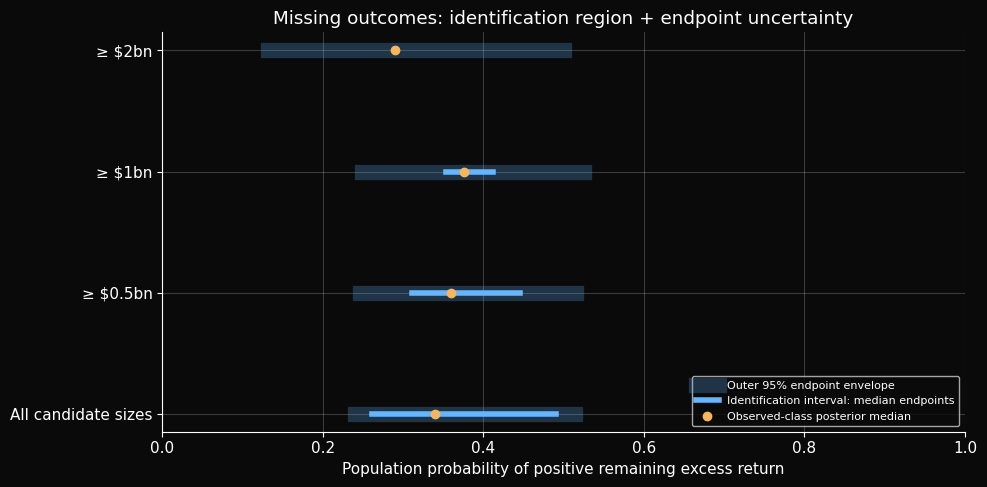

In [17]:
bounds = pd.read_csv(RESULTS / 'missing_outcomes.csv')
display(bounds.query("cutoff == 10 and event == 'positive'")
        [['threshold', 'scope', 'N', 'n', 'pi', 'width', 'observed_rate',
          'q_lo', 'q_hi', 'lower_median', 'upper_median', 'lower_lo', 'upper_hi']])

endpoints = bounds.query("cutoff == 10 and scope == 'endpoint' and event == 'positive'")
endpoints = endpoints.sort_values('threshold')
fig, ax = plt.subplots()
for index, row in enumerate(endpoints.itertuples(index=False)):
    ax.plot([row.lower_lo, row.upper_hi], [index, index],
            linewidth=11, color=COLORS[0], alpha=0.25,
            label='Outer 95% endpoint envelope' if index == 0 else None)
    ax.plot([row.lower_median, row.upper_median], [index, index],
            linewidth=4, color=COLORS[0],
            label='Identification interval: median endpoints' if index == 0 else None)
    ax.plot(row.q_median, index, 'o', color=COLORS[1],
            label='Observed-class posterior median' if index == 0 else None)
labels = [
    'All candidate sizes' if threshold == 0 else f'≥ ${threshold / 1e9:g}bn'
    for threshold in endpoints.threshold
]
ax.set_yticks(range(len(endpoints)), labels)
ax.set(xlim=(0, 1), xlabel='Population probability of positive remaining excess return',
       title='Missing outcomes: identification region + endpoint uncertainty')
ax.legend(loc='lower right', fontsize=8)
fig.tight_layout()
plt.show()


# 16. Large and mega-IPO study

I examine whether the broad-sample models are useful for larger IPOs. I do not fit a separate large-IPO model: the final sample contains only 18 IPOs at or above \$1bn and four at or above \$2bn. I fit the regressions on the broader sample, use log proceeds continuously, and evaluate exploratory \$500m+, \$1bn+ and \$2bn+ groups.

I first test an early-price-by-size interaction at day 10:

$$
\mu=\alpha+\gamma z(\log\mathrm{Proceeds})+\beta_P z(\mathrm{EarlyCAR})
+\beta_{P\times S}z(\mathrm{EarlyCAR})z(\log\mathrm{Proceeds}).
$$

The development log-score increment is $-0.0057$, with a 95% IPO-bootstrap interval of $[-0.0144,0.0029]$. I omit the interaction because this comparison does not establish an improvement; it does not prove that size-dependent relationships are absent.

I use `results/size_performance.csv` for the subgroup metrics. At day 10 in the final \$1bn+ group, M3 has average log score $-0.3820$ compared with $-0.6092$ for M0, and CRPS falls from $0.2403$ to $0.2085$.

I also inspect `results/size_comparisons.csv`. For these 18 IPOs, the paired log-score gains and 95% IPO-bootstrap intervals are

$$
\begin{aligned}
\text{day 5, M1--M0}:&\quad0.0323\;[0.0107,0.0555],\\
\text{day 10, M2--M1}:&\quad0.1741\;[0.0038,0.3789],\\
\text{day 20, M2--M1}:&\quad0.1303\;[0.0016,0.2929],\\
\text{day 10, M3--M2}:&\quad0.0516\;[0.0048,0.1031].
\end{aligned}
$$

These comparisons suggest possible value in the early signals, but I treat them as exploratory because of the small samples, multiple comparisons and independent-IPO bootstrap assumption.

Although the \$1bn+ intervals have relatively high coverage, I do not equate this with calibrated event probabilities. At day 10, M3 assigns an average outperformance probability of 45.5%, while only four of 18 IPOs outperform (22.2%). The sample is too small for a firm subgroup conclusion. With four \$2bn+ IPOs, I cannot support a separate mega-IPO claim.


# 17. Limitations

I see the following limits to the interpretation and use of this study:

- **Data quality and sample selection.** I require sufficiently complete observable histories. The public archive may contain ticker, classification, delisting or adjustment errors, and I do not include the collection pipeline needed to reconstruct the inputs. Population event-rate bounds do not remove regression-selection concerns.
- **Calibration.** I observe substantial undercoverage in the final broad cohort. I would need better calibrated distributions before treating the stated probabilities as reliable for decisions.
- **Common calendar shocks.** My likelihood treats observations as conditionally independent, and my paired bootstrap resamples IPOs independently. Benchmark adjustment does not remove all shared shocks, so both parameter and score uncertainty may be understated.
- **Limited validation.** I use two development blocks and one final block. Small subgroups and multiple exploratory comparisons make large-IPO and rare-event conclusions especially fragile. Once I use the final results to redesign a model, I would need another holdout for confirmation.
- **Empirical-Bayes priors.** I calibrate prior scales from training outcomes and hold them fixed in sampling. I do not propagate uncertainty in that calibration.
- **Return interpretation.** I model index-relative price returns, not risk-adjusted alpha or a transaction-cost-aware strategy. Student-$t$ log returns do not imply finite expected arithmetic wealth, so I report quantiles and probabilities.
- **Separate forecasting horizons.** I use different conditional models at days 1, 5, 10 and 20. I do not estimate one recursively updated issuer state or validate arbitrary daily cutoffs.
- **Unmodelled market conditions.** I do not include VIX, sector or broader pre-listing conditions in the fitted predictors. These are possible extensions rather than effects established here.
- **Descriptive activity analysis.** I use future reference levels and select the decay form on the later cohort. I keep that exercise separate from the chronological forecast validation.


# 18. Model application to a future IPO

I apply the saved day-10 model to an illustrative IPO, NEWCO, using ten observed sessions. I keep the population model fixed and do not add NEWCO to training.

Before trading, I use offering size for a reference distribution of first-close-to-day-60 performance. The API validates the offer price as metadata, but does not use it as a predictor or forecast the initial IPO move. After trading begins, I supply closing prices, volumes and benchmark returns through the chosen cutoff to forecast

$$
Y_{i,t}=\sum_{s=t+1}^{60}(r_{i,s}-r_{b,s}).
$$

For the synthetic NEWCO inputs below, I obtain a day-10 predictive median of $-0.2205$. Exponentiating gives $e^{-0.2205}=0.8021$, or a median benchmark-relative return of approximately $-19.8\%$ from the close of day 10 to day 60.

I also obtain

$$
P(Y_{10}>0)=22.8\%,\qquad P(Y_{10}<\log(0.8))=49.1\%.
$$

The 80% predictive interval is $[-0.6234,0.2095]$ in log-return units, corresponding to approximately $[-46.4\%,+23.3\%]$ in relative simple-return terms.

I interpret these as an illustration of the API, not a validated forecast for an actual issuer. The wide interval reflects substantial remaining uncertainty, and the final-cohort undercoverage means that I cannot assume its nominal 80% probability is reliable.


In [18]:
# Illustrative IPO: the arrays contain observed sessions 1–10 only.
ipo_name = "NEWCO"
ipo_date = "2026-09-10"
offer_price = 50.00
ipo_proceeds = 1_200_000_000
t = 10

prices = np.array([
    54.00, 55.20, 53.80, 54.60, 56.10,
    55.40, 57.00, 58.20, 57.60, 59.10,
])
volume = np.array([
    65_000_000, 48_000_000, 39_000_000, 32_000_000, 29_000_000,
    24_000_000, 22_000_000, 20_000_000, 18_500_000, 17_000_000,
])
benchmark_returns = np.array([
    0.0040, 0.0025, -0.0060, 0.0030, 0.0045,
    -0.0020, 0.0055, 0.0035, -0.0015, 0.0050,
])

offer = dict(offer_price=offer_price, ipo_proceeds=ipo_proceeds, ipo_date=ipo_date)
prior = forecast(baseline, **offer)
updated = forecast(models[t], **offer, prices=prices, volume=volume,
                   benchmark_returns=benchmark_returns)

summary = updated.copy()
summary.pop("draws_log_excess_return")
for name, value in summary.items():
    if isinstance(value, float):
        summary[name] = round(value, 4)
    elif isinstance(value, tuple):
        summary[name] = tuple(round(number, 4) for number in value)
display(pd.Series(summary).to_frame(f"{ipo_name}: day-{t} forecast"))

,NEWCO: day-10 forecast
calibration_status,Research forecast: broad-cohort intervals unde...
cutoff,10
model,M3
p_positive,0.2278
p_loss20,0.491
median_log,-0.2205
interval50_log,"(-0.3949, -0.0293)"
interval80_log,"(-0.6234, 0.2095)"
interval95_log,"(-1.0586, 0.6037)"


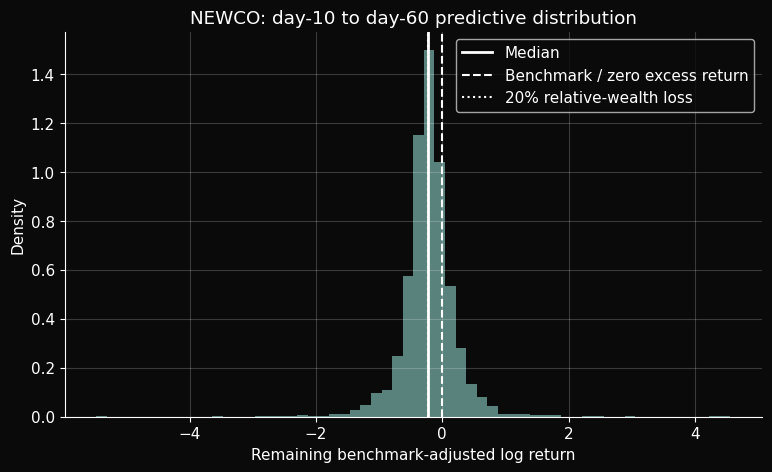

In [19]:
draws = updated["draws_log_excess_return"]
median = np.median(draws)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(draws, bins=60, density=True, alpha=0.6)
ax.axvline(median, linewidth=2, label="Median")
ax.axvline(0, linestyle="--", linewidth=1.5,
           label="Benchmark / zero excess return")
ax.axvline(np.log(0.8), linestyle=":", linewidth=1.5,
           label="20% relative-wealth loss")
ax.set(title=f"{ipo_name}: day-{t} to day-60 predictive distribution",
       xlabel="Remaining benchmark-adjusted log return", ylabel="Density")
ax.legend()
plt.show()